In [1]:
!pip install textblob
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [3]:
df_telerev = pd.read_csv('df_telerev.csv', skip_blank_lines=True)
df_telerev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b6cb4c8f-60a7-48e5-a6c8-945480ce4888,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,malah berbayar,1,0,12.5.1,2026-03-16 13:17:55,NaN,NaN,12.5.1
1,18d661cf-8c17-487d-9223-5a60909511c2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,daftar akun harus premium,1,0,NaN,2026-03-16 12:47:10,NaN,NaN,NaN
2,dbf6ed43-961c-4ab2-a913-30cf7c1d411c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,masa dftar akun hrus byr🤣🤣🤣,1,0,12.5.1,2026-03-16 12:38:20,NaN,NaN,12.5.1
3,772026f9-e4d5-4550-bb5a-e10323751c2e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,KENAPA TELEGRAM SAYA SERING FORCE CLOSEEE,1,0,12.5.1,2026-03-16 12:06:50,Maaf atas masalah yang Anda alami. Silakan lap...,2026-03-16 13:16:05,12.5.1
4,058a6794-358f-4532-a7a2-9c4550ee491a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,di paksa premium,1,0,NaN,2026-03-16 11:30:10,NaN,NaN,NaN


In [4]:
# Selected Columns
df_analysis = df_telerev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]
df_analysis

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,malah berbayar,1,0,12.5.1,2026-03-16 13:17:55,NaN,NaN
1,daftar akun harus premium,1,0,NaN,2026-03-16 12:47:10,NaN,NaN
2,masa dftar akun hrus byr🤣🤣🤣,1,0,12.5.1,2026-03-16 12:38:20,NaN,NaN
3,KENAPA TELEGRAM SAYA SERING FORCE CLOSEEE,1,0,12.5.1,2026-03-16 12:06:50,Maaf atas masalah yang Anda alami. Silakan lap...,2026-03-16 13:16:05
4,di paksa premium,1,0,NaN,2026-03-16 11:30:10,NaN,NaN
...,...,...,...,...,...,...,...
99995,"Gak bisa buat akun, rusakk",1,0,NaN,2023-12-24 13:03:34,NaN,NaN
99996,Nomor tiba tiba ter blokir,1,0,NaN,2023-12-24 12:54:35,NaN,NaN
99997,ok,4,0,10.4.0,2023-12-24 12:45:28,NaN,NaN
99998,Saturasi nggak bisa login padahal caranya udah...,1,2,10.3.2,2023-12-24 12:27:25,NaN,NaN


# Data Cleaning

In [5]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   content               100000 non-null  object
 1   score                 100000 non-null  int64 
 2   thumbsUpCount         100000 non-null  int64 
 3   reviewCreatedVersion  65479 non-null   object
 4   at                    100000 non-null  object
 5   replyContent          29036 non-null   object
 6   repliedAt             29036 non-null   object
dtypes: int64(2), object(5)
memory usage: 5.3+ MB


In [6]:
df_analysis.isnull().sum()

,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,34521
at,0
replyContent,70964
repliedAt,70964


In [7]:
df_analysis.duplicated().sum()

np.int64(0)

## Remove Missing "Content" Value

In [8]:
df_analysis = df_analysis.dropna(subset=["content"]).copy()
df_analysis = df_analysis[df_analysis["content"].str.strip() != ""].copy()

## Remove Abnormal "Score" Value

In [9]:
df_analysis = df_analysis.dropna(subset=["score"]).copy()
df_analysis = df_analysis[df_analysis["score"].between(1, 5)].copy()

## Only Take 20k Data

In [10]:
df_analysis = df_analysis.head(20000).copy()

## Correcting Datatype

In [11]:
df_analysis["at"] = pd.to_datetime(df_analysis["at"], errors="coerce")
df_analysis["repliedAt"] = pd.to_datetime(df_analysis["repliedAt"], errors="coerce")

## Cleaning Content (Make new column)

In [12]:
df_analysis["content_clean"] = df_analysis["content"].astype(str)

### Lowercase

In [13]:
df_analysis["content_clean"] = df_analysis["content_clean"].str.lower()

### Removing Noise

In [14]:
#Delete URL
def remove_url(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text)

df_analysis["content_clean"] = df_analysis["content_clean"].apply(remove_url)

In [15]:
def clean_text_basic(text):
    text = re.sub(r'@\w+', '', text)              # hapus mention
    text = re.sub(r'#\w+', '', text)              # hapus hashtag
    text = re.sub(r'\d+', '', text)               # hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)          # hapus tanda baca
    text = re.sub(r'_', ' ', text)                # underscore ke spasi
    text = re.sub(r'\s+', ' ', text).strip()      # rapikan spasi
    return text

df_analysis["content_clean"] = df_analysis["content_clean"].apply(clean_text_basic)

In [16]:
#Delete Emoji
def remove_emoji(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002700-\U000027BF"
        u"\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

df_analysis["content_clean"] = df_analysis["content_clean"].apply(remove_emoji)

In [17]:
#Remove short text
df_analysis["word_count"] = df_analysis["content_clean"].apply(lambda x: len(x.split()))
df_analysis = df_analysis[df_analysis["word_count"] >= 2].copy()

In [18]:
df_analysis["content_clean"]

,content_clean
0,malah berbayar
1,daftar akun harus premium
2,masa dftar akun hrus byr
3,kenapa telegram saya sering force closeee
4,di paksa premium
...,...
19995,aplikasi tolol susah banget login
19996,tele asu
19997,bagus tapi banyak bot nya
19998,kalo email nya udah hilang saya tidak dapat ma...


### Normalize Slang

In [19]:
df_clean = df_analysis.copy()

# slang dictionary
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "ngga": "tidak",
    "nggak": "tidak",
    "tak": "tidak",
    "bgt": "banget",
    "bgtt": "banget",
    "udh": "sudah",
    "sdh": "sudah",
    "blm": "belum",
    "apk": "aplikasi",
    "app": "aplikasi",
    "tp": "tapi",
    "yg": "yang",
    "jg": "juga",
    "krn": "karena",
    "dr": "dari",
    "dgn": "dengan",
    "aja": "saja"
}

def normalize_slang(text):
    return " ".join([slang_dict.get(word, word) for word in text.split()])

df_clean["content_clean"] = df_clean["content_clean"].apply(normalize_slang)

### Remove Stopwords + Stemming

In [20]:
!pip install Sastrawi

In [21]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# stopword
factory_stop = StopWordRemoverFactory()
stopwords = set(factory_stop.get_stop_words())

# bisa tambah custom stopwords
custom_stopwords = {
    "nya", "nih", "sih", "dong", "deh", "lah", "kok"
}
stopwords = stopwords.union(custom_stopwords)

# stemmer
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

def preprocess_text(text):
    tokens = text.split()  # tokenization sederhana
    tokens = [word for word in tokens if word not in stopwords]  # stopword removal
    text = " ".join(tokens)
    text = stemmer.stem(text)  # stemming
    return text

df_clean["content_tfidf"] = df_clean["content_clean"].apply(preprocess_text)

In [22]:
df_clean["word_count"] = df_clean["content_tfidf"].apply(lambda x: len(x.split()))
df_clean = df_clean[df_clean["word_count"] >= 2].copy()

In [23]:
df_clean[["content", "content_clean", "content_tfidf"]].head(10)

,content,content_clean,content_tfidf
0,malah berbayar,malah berbayar,malah bayar
1,daftar akun harus premium,daftar akun harus premium,daftar akun premium
2,masa dftar akun hrus byr🤣🤣🤣,masa dftar akun hrus byr,masa dftar akun hrus byr
3,KENAPA TELEGRAM SAYA SERING FORCE CLOSEEE,kenapa telegram saya sering force closeee,telegram sering force closeee
4,di paksa premium,di paksa premium,paksa premium
5,aplikasi banyak bug dh bayar masih banyak bug ...,aplikasi banyak bug dh bayar masih banyak bug ...,aplikasi banyak bug dh bayar banyak bug kontooo
6,saya di paksa untuk membeli premium,saya di paksa untuk membeli premium,paksa beli premium
7,pacarku selingkuh di apk ini ☺️,pacarku selingkuh di aplikasi ini,pacar selingkuh aplikasi
8,kenapa saat saya mau login dengan NO HP selalu...,kenapa saat saya mau login dengan no hp selalu...,mau login no hp selalu gak pemberitahuan no hp...
9,"kenapa logika sekarang harus bayar, makin jele...",kenapa logika sekarang harus bayar makin jelek...,logika sekarang bayar makin jelek


# EDA

## Data Overview

In [24]:
# Display dataset info and first few rows
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17602 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   content               17602 non-null  object        
 1   score                 17602 non-null  int64         
 2   thumbsUpCount         17602 non-null  int64         
 3   reviewCreatedVersion  10777 non-null  object        
 4   at                    17602 non-null  datetime64[ns]
 5   replyContent          2990 non-null   object        
 6   repliedAt             2990 non-null   datetime64[ns]
 7   content_clean         17602 non-null  object        
 8   word_count            17602 non-null  int64         
 9   content_tfidf         17602 non-null  object        
dtypes: datetime64[ns](2), int64(3), object(5)
memory usage: 1.5+ MB


In [25]:
# Display dataset first few rows
df_clean.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,content_clean,word_count,content_tfidf
0,malah berbayar,1,0,12.5.1,2026-03-16 13:17:55,NaN,NaT,malah berbayar,2,malah bayar
1,daftar akun harus premium,1,0,NaN,2026-03-16 12:47:10,NaN,NaT,daftar akun harus premium,3,daftar akun premium
2,masa dftar akun hrus byr🤣🤣🤣,1,0,12.5.1,2026-03-16 12:38:20,NaN,NaT,masa dftar akun hrus byr,5,masa dftar akun hrus byr
3,KENAPA TELEGRAM SAYA SERING FORCE CLOSEEE,1,0,12.5.1,2026-03-16 12:06:50,Maaf atas masalah yang Anda alami. Silakan lap...,2026-03-16 13:16:05,kenapa telegram saya sering force closeee,4,telegram sering force closeee
4,di paksa premium,1,0,NaN,2026-03-16 11:30:10,NaN,NaT,di paksa premium,2,paksa premium


## Missing Values Analysis

In [26]:
missing_values = df_clean.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     6825
at                          0
replyContent            14612
repliedAt               14612
content_clean               0
word_count                  0
content_tfidf               0
dtype: int64


## Review Score Distribution

/tmp/ipykernel_6647/848601184.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['score'], palette="viridis")


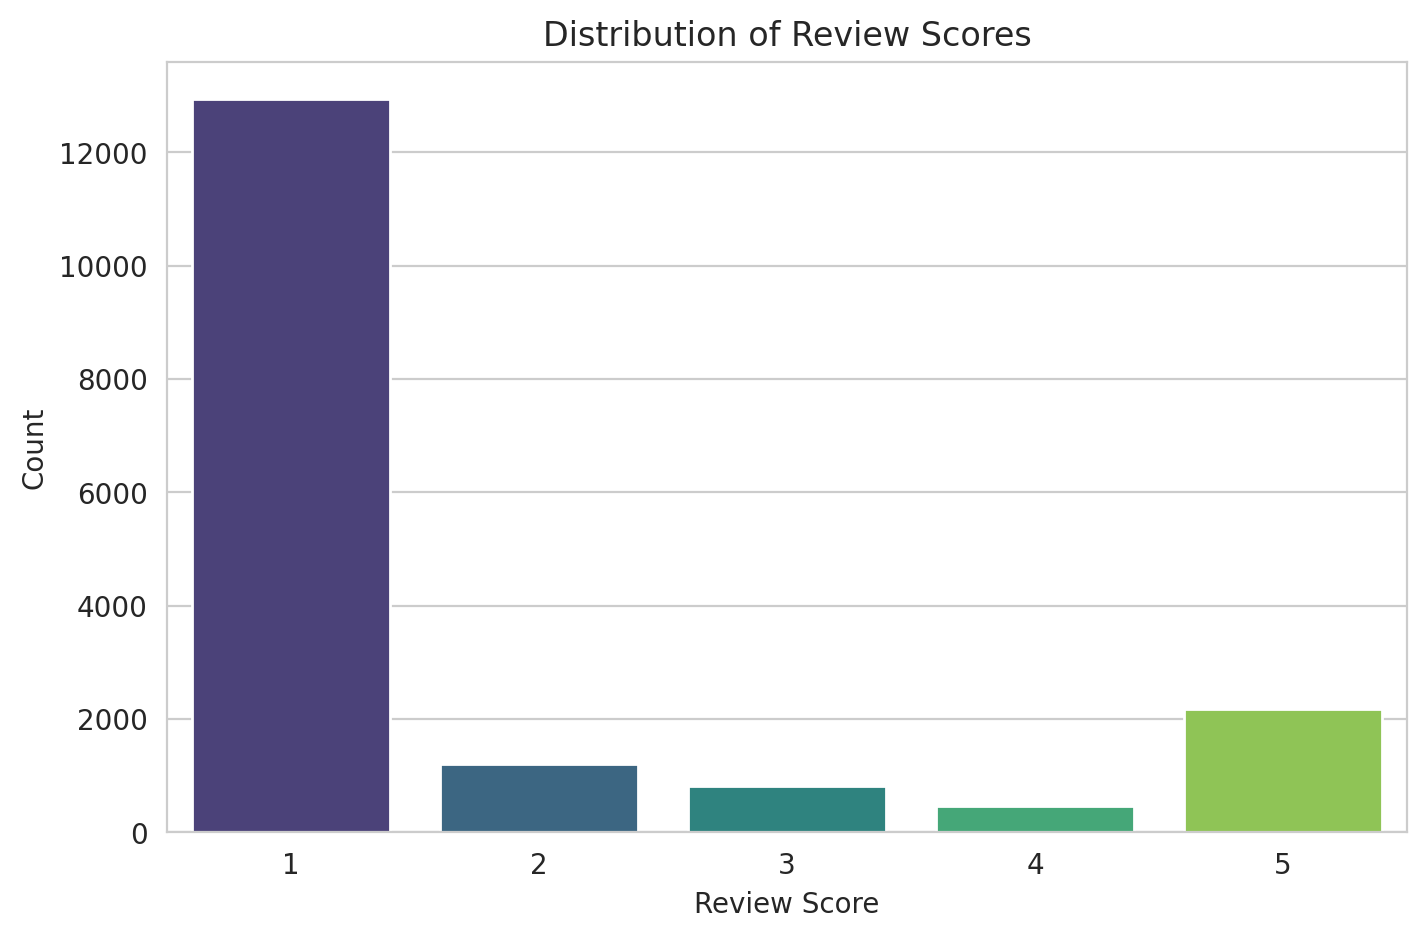

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_clean['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

## Review Trends Over Time

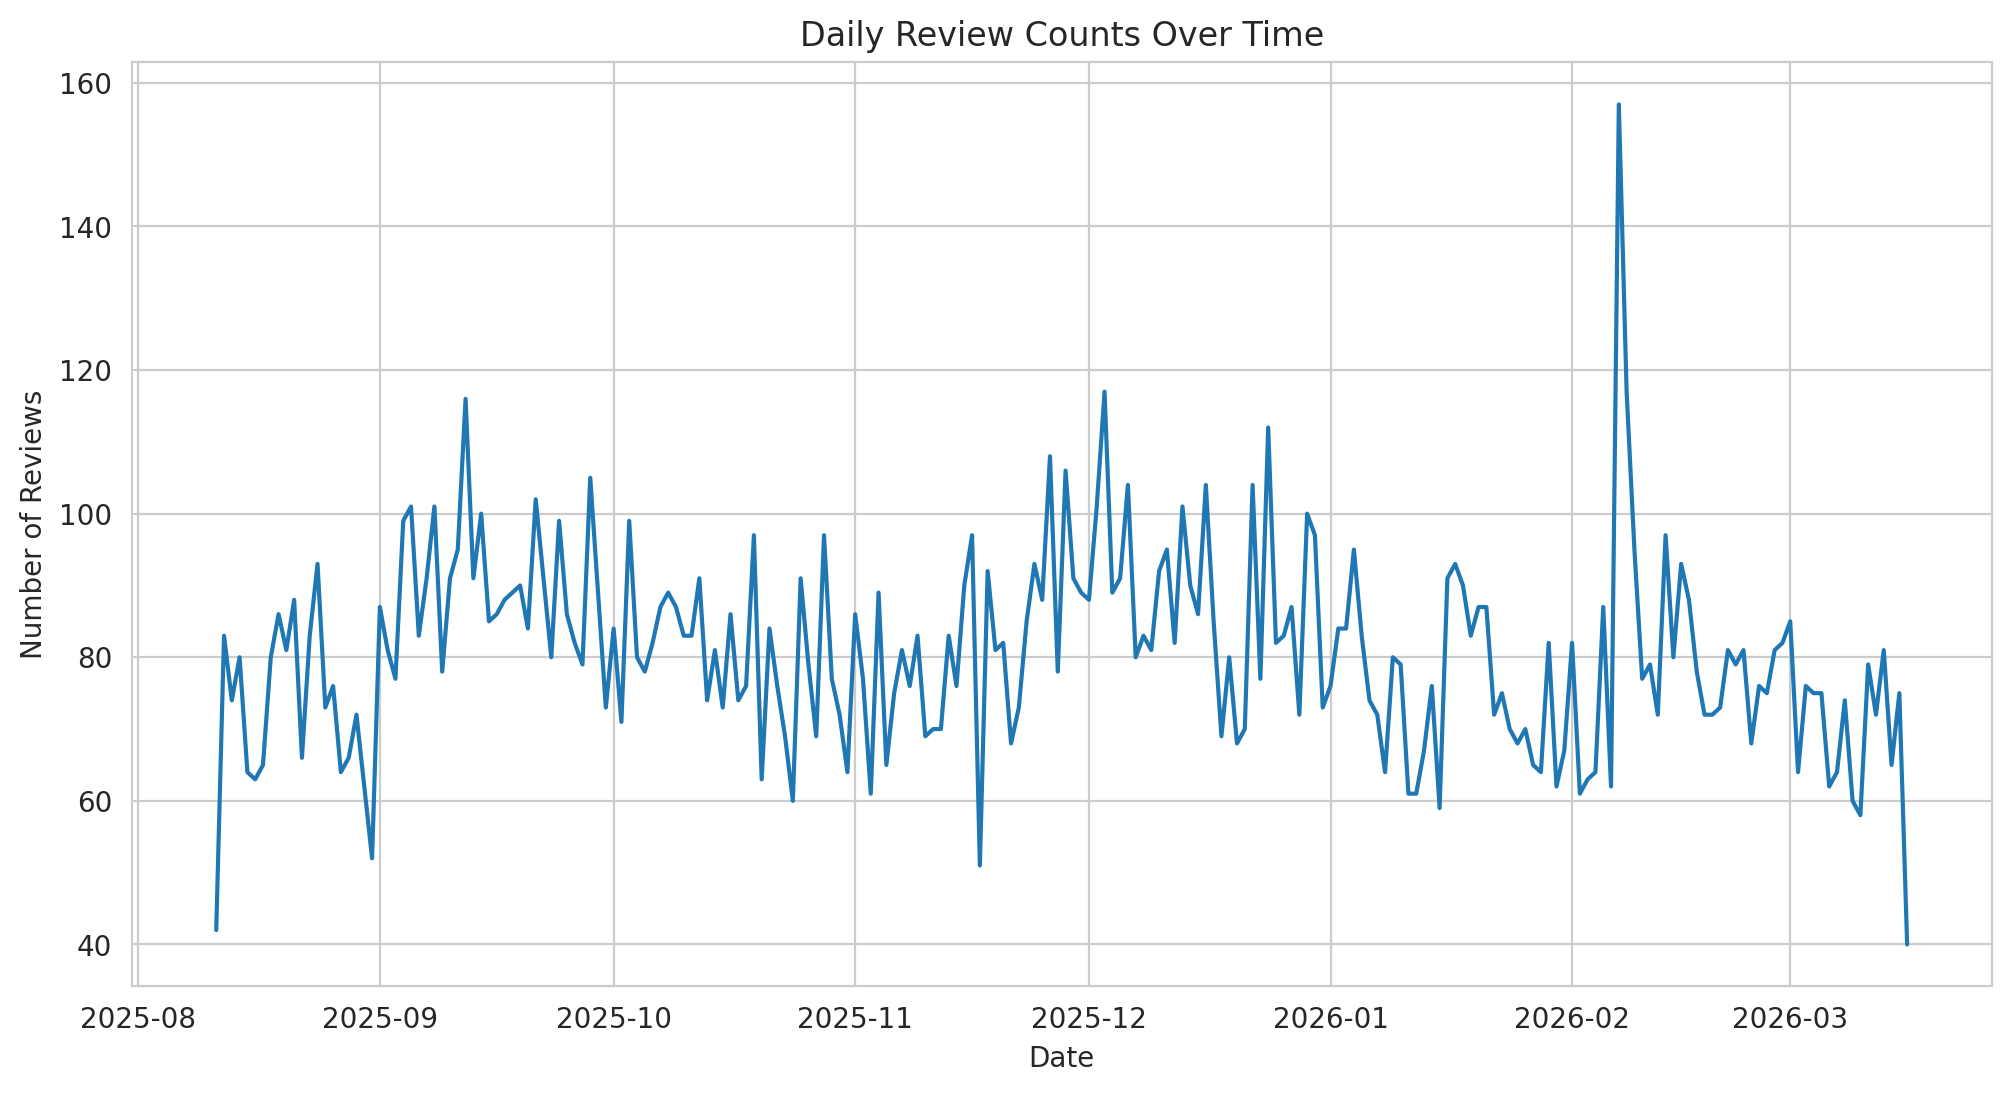

In [28]:
df_clean['review_date'] = df_clean['at'].dt.date
review_trend = df_clean.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

In [29]:
df_clean.to_csv('df_clean.csv', index=False)